# Week 4 — Neural Network Classifier

## AI-Based Smart Queue and Time Management System

**Bishwadeep Rai**  
Westcliff University, California  
TECH 405: Artificial Neural Network and Deep Learning  
Professor Aashish Dhakal

---

## 1. Introduction

In this notebook, a **neural-network classifier** is implemented as part of the Week 4 assignment. In the bigger project, RNN/LSTM models will be used for predicting waiting time values. This week, however, a **classifier** should be trained with hyperparameter tuning and evaluated through a confusion matrix, precision, recall, and F-score.

**Prediction task.** Will the call be compliant with the service standard (`meets_standard`)?

Call complies with the service standard if the caller waits up to 60 seconds. The 60-second limit was checked against the data in the uploaded CSV (see the leakage check section below). This piece of information is **not** used as an input to the model.

**Framework:** TensorFlow / Keras  
**Random seed:** 42

The values shown after each experiment in this notebook are calculated by executing the corresponding cells. The interpretations in the markdown cells apply to the run of `ml_experiments/run_experiments.py` with seed-42 on this dataset so that the write-up remains consistent with the generated figures in `docs/figures/`.

## 2. Dataset and problem definition

**Filename:** `simulated_call_centre.csv`  
**Dataset Source:** Kaggle *Call Centre Queue Simulation* (CC BY-SA 4.0)  
**Simulation environment (as stated in the dataset description of Week 2):** Four agents, weekdays 08:00-18:00, average service time roughly 5 minutes, 60 seconds to answer.

| Column | Role |
|--------|------|
| `call_id` | Identifier — excluded |
| `date` | Arrival date — time features extracted |
| `daily_caller` | Queue position that day — used |
| `call_started` | Arrival time — time features extracted |
| `call_answered` | Post-event — excluded |
| `call_ended` | Post-event — excluded |
| `wait_length` | Post-event and target constructor — excluded |
| `service_length` | Post-event — excluded |
| `meets_standard` | **Target** |

This is binary classification:

- `True` = call met the 60-second standard  
- `False` = call did not meet the standard


---
##  Data understanding




In [1]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    confusion_matrix, classification_report, ConfusionMatrixDisplay,
    precision_score, recall_score, f1_score, accuracy_score
)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

print('TensorFlow:', tf.__version__)
print('Seed     :', SEED)

c:\Users\MSI-1\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
c:\Users\MSI-1\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


TensorFlow: 2.18.0
Seed     : 42


In [2]:
# Resolve the CSV whether the notebook is opened from notebooks/ or the project root
CANDIDATES = [
    os.path.join('..', 'data', 'simulated_call_centre.csv'),
    os.path.join('data', 'simulated_call_centre.csv'),
    os.path.join('..', 'simulated_call_centre.csv'),
]
CSV_PATH = next(p for p in CANDIDATES if os.path.exists(p))
print('Loading:', os.path.abspath(CSV_PATH))

df_raw = pd.read_csv(CSV_PATH)
print('\nShape:', df_raw.shape)
print('\nColumns and dtypes:')
print(df_raw.dtypes)
print('\nFirst 5 rows:')
display(df_raw.head())

Loading: c:\Users\MSI-1\OneDrive\Desktop\Smart Queue & Time Management System\data\simulated_call_centre.csv

Shape: (51708, 9)

Columns and dtypes:
call_id           int64
date                str
daily_caller      int64
call_started        str
call_answered       str
call_ended          str
wait_length       int64
service_length    int64
meets_standard     bool
dtype: object

First 5 rows:


,call_id,date,daily_caller,call_started,call_answered,call_ended,wait_length,service_length,meets_standard
0,1,2021-01-01,1,8:00:00 AM,8:00:00 AM,8:14:22 AM,0,863,True
1,2,2021-01-01,2,8:02:42 AM,8:02:42 AM,8:07:31 AM,0,289,True
2,3,2021-01-01,3,8:08:24 AM,8:08:24 AM,8:10:13 AM,0,108,True
3,4,2021-01-01,4,8:09:37 AM,8:09:37 AM,8:13:45 AM,0,247,True
4,5,2021-01-01,5,8:11:10 AM,8:11:10 AM,8:15:28 AM,0,258,True


In [3]:
print('Random 5 rows:')
display(df_raw.sample(5, random_state=SEED))
print('\nDescriptive statistics:')
display(df_raw.describe(include='all'))

Random 5 rows:


,call_id,date,daily_caller,call_started,call_answered,call_ended,wait_length,service_length,meets_standard
7673,7674,2021-03-15,67,12:26:53 PM,12:26:53 PM,12:27:57 PM,0,64,True
20436,20437,2021-06-25,163,5:41:16 PM,5:41:16 PM,5:42:28 PM,0,72,True
14737,14738,2021-05-13,76,1:05:31 PM,1:05:31 PM,1:16:15 PM,0,644,True
43740,43741,2021-11-22,72,10:43:22 AM,10:43:22 AM,10:50:06 AM,0,404,True
3227,3228,2021-02-02,77,1:21:28 PM,1:21:28 PM,1:25:41 PM,0,253,True



Descriptive statistics:


,call_id,date,daily_caller,call_started,call_answered,call_ended,wait_length,service_length,meets_standard
count,51708.000000,51708,51708.000000,51708,51708,51708,51708.000000,51708.000000,51708
unique,NaN,261,NaN,27403,27366,27486,NaN,NaN,2
top,NaN,2021-12-10,NaN,8:00:00 AM,8:00:00 AM,11:54:17 AM,NaN,NaN,True
freq,NaN,297,NaN,261,261,8,NaN,NaN,47481
mean,25854.500000,NaN,104.193239,NaN,NaN,NaN,17.034927,299.102595,NaN
std,14926.958196,NaN,64.952880,NaN,NaN,NaN,64.060769,299.865751,NaN
min,1.000000,NaN,1.000000,NaN,NaN,NaN,0.000000,0.000000,NaN
25%,12927.750000,NaN,50.000000,NaN,NaN,NaN,0.000000,86.000000,NaN
50%,25854.500000,NaN,100.000000,NaN,NaN,NaN,0.000000,208.000000,NaN
75%,38781.250000,NaN,150.000000,NaN,NaN,NaN,0.000000,414.000000,NaN


In [4]:
print('Missing values:\n', df_raw.isnull().sum())
print('\nDuplicate rows:', int(df_raw.duplicated().sum()))
print('Negative wait_length:', int((df_raw['wait_length'] < 0).sum()))
print('service_length <= 0 :', int((df_raw['service_length'] <= 0).sum()))
print('meets_standard unique:', df_raw['meets_standard'].unique())
print('call_id unique == rows:', df_raw['call_id'].nunique() == len(df_raw))

Missing values:
 call_id           0
date              0
daily_caller      0
call_started      0
call_answered     0
call_ended        0
wait_length       0
service_length    0
meets_standard    0
dtype: int64

Duplicate rows: 0
Negative wait_length: 0
service_length <= 0 : 88
meets_standard unique: [ True False]
call_id unique == rows: True


In [5]:
# Date/time columns are not ordinary strings.
# date is YYYY-MM-DD; call times are 12-hour clock strings such as '8:00:00 AM'.
df = df_raw.copy()
df['date'] = pd.to_datetime(df['date'])

def combine_date_time(date_col, time_str_col):
    t = pd.to_datetime(time_str_col, format='%I:%M:%S %p', errors='coerce')
    return date_col + pd.to_timedelta(
        t.dt.hour * 3600 + t.dt.minute * 60 + t.dt.second, unit='s')

df['call_started_dt']  = combine_date_time(df['date'], df['call_started'])
df['call_answered_dt'] = combine_date_time(df['date'], df['call_answered'])
df['call_ended_dt']    = combine_date_time(df['date'], df['call_ended'])

print('call_started range :', df['call_started_dt'].min(), '->', df['call_started_dt'].max())
print('Unique days        :', df['date'].nunique())
print('NaT in call_started:', int(df['call_started_dt'].isnull().sum()))
print('Weekdays present   :', sorted(df['date'].dt.dayofweek.unique().tolist()))

call_started range : 2021-01-01 08:00:00 -> 2021-12-31 17:58:15
Unique days        : 261
NaT in call_started: 0
Weekdays present   : [0, 1, 2, 3, 4]


**Data-quality notes from the uploaded file**

- Shape is **51,708 rows × 9 columns**.
- No missing values and no duplicate rows.
- `meets_standard` is a boolean.
- **88** rows have `service_length == 0`. These are kept. Zero-length service can occur in a simulation (immediate hang-up / zero talk time) and that column is not used as a feature, so dropping them would discard valid arrival events without improving the classifier.


---
## Part 2 — Exploratory analysis for the classifier

### Data leakage check

If `meets_standard` is a hard threshold on `wait_length`, then using `wait_length` as a feature is not prediction. It is copying the label rule.


In [6]:
true_max = df.loc[df['meets_standard'] == True, 'wait_length'].max()
false_min = df.loc[df['meets_standard'] == False, 'wait_length'].min()
mismatches = int(((df['wait_length'] <= 60) != df['meets_standard']).sum())

print('Max wait_length among True  :', true_max)
print('Min wait_length among False :', false_min)
print('Rows where (wait_length <= 60) disagrees with meets_standard:', mismatches)
print()
print('Decision: exclude wait_length, call_answered, call_ended, and service_length.')

Max wait_length among True  : 60
Min wait_length among False : 61
Rows where (wait_length <= 60) disagrees with meets_standard: 0

Decision: exclude wait_length, call_answered, call_ended, and service_length.


Recorded result on this CSV: max wait among True is **60**, min wait among False is **61**, mismatches = **0**.  
So `meets_standard` is exactly `wait_length <= 60`.

**Availability at prediction time** (new call just arriving):

| Column | Available? | Decision |
|--------|------------|----------|
| `call_id` | Identifier only | Exclude |
| `date`, `call_started`, `daily_caller` | Yes | Use / extract features |
| `call_answered`, `call_ended` | No — after the wait | Exclude |
| `wait_length` | No — and it *is* the label rule | Exclude |
| `service_length` | No — after the call ends | Exclude |

> **Class distribution**


True : 47,481 (91.83%)
False: 4,227 (8.17%)
Imbalance ratio True:False = 11.23


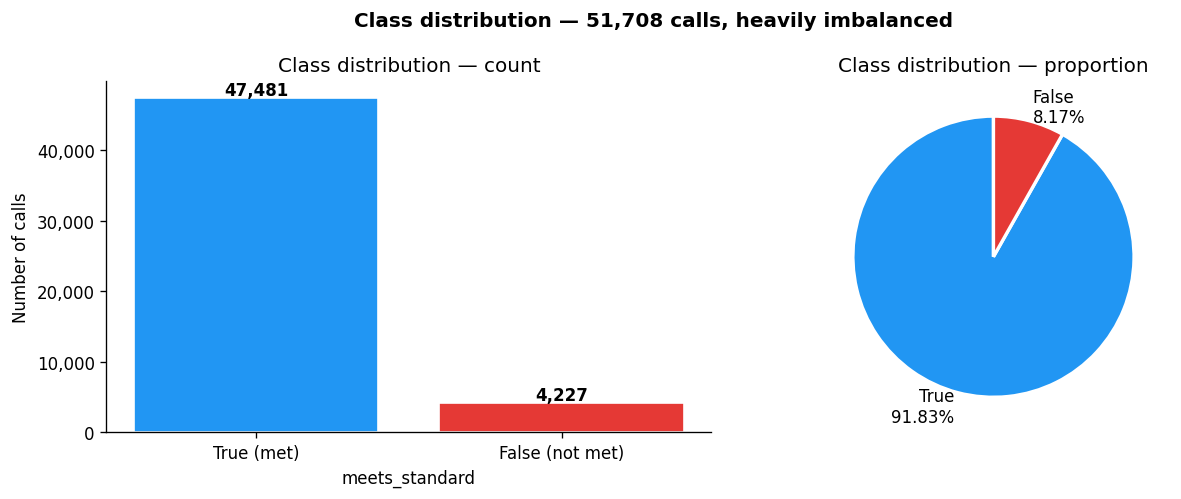

In [7]:
vc = df['meets_standard'].value_counts()
vc_pct = df['meets_standard'].value_counts(normalize=True) * 100
print('True :', f"{vc[True]:,}", f'({vc_pct[True]:.2f}%)')
print('False:', f"{vc[False]:,}", f'({vc_pct[False]:.2f}%)')
print('Imbalance ratio True:False =', round(vc[True] / vc[False], 2))

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
axes[0].bar(['True (met)', 'False (not met)'], [vc[True], vc[False]],
            color=['#2196F3', '#E53935'], edgecolor='white')
for i, v in enumerate([vc[True], vc[False]]):
    axes[0].text(i, v + 400, f'{v:,}', ha='center', fontweight='bold')
axes[0].set_title('Class distribution — count')
axes[0].set_xlabel('meets_standard')
axes[0].set_ylabel('Number of calls')
axes[0].yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
axes[1].pie([vc[True], vc[False]],
            labels=[f'True\n{vc_pct[True]:.2f}%', f'False\n{vc_pct[False]:.2f}%'],
            colors=['#2196F3', '#E53935'], startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Class distribution — proportion')
plt.suptitle(f'Class distribution — {len(df):,} calls, heavily imbalanced', fontweight='bold')
plt.tight_layout()
plt.show()

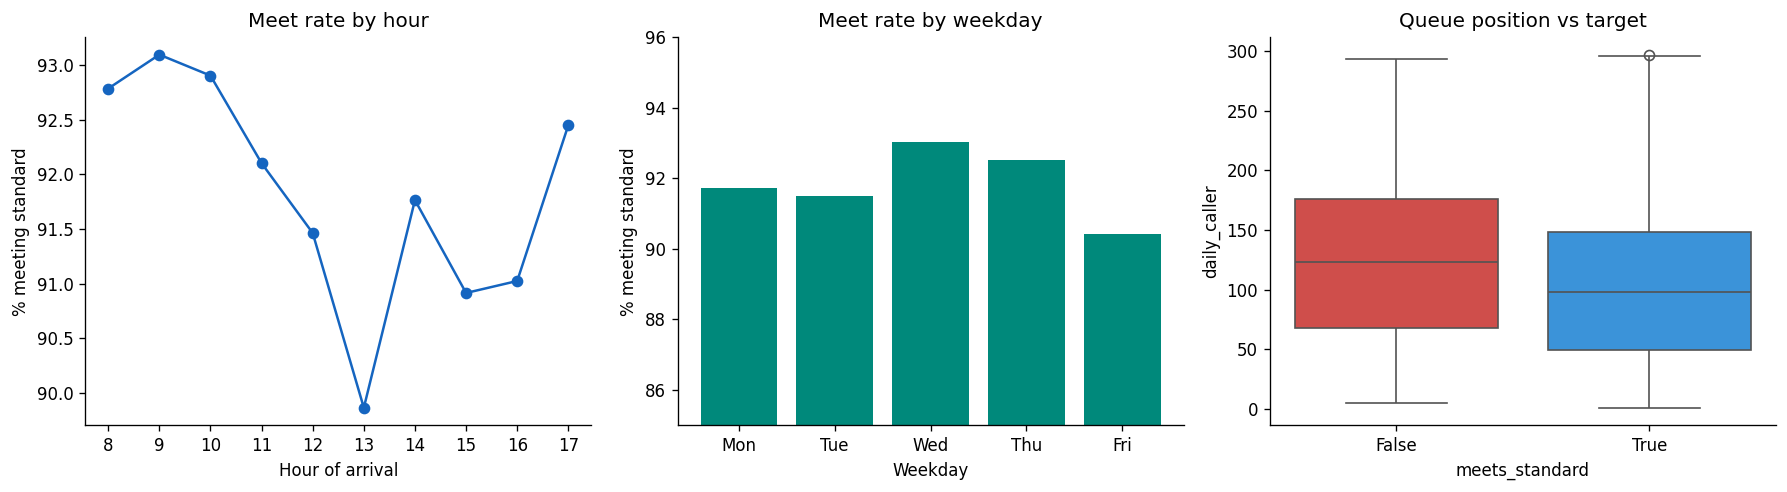

Lowest hour meet-rate : hour 13 89.86%
Lowest weekday        : Fri 90.41%


In [8]:
df['hour'] = df['call_started_dt'].dt.hour
df['day_of_week'] = df['date'].dt.dayofweek
df['month'] = df['date'].dt.month
df['day_of_month'] = df['date'].dt.day

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))

hour_rate = df.groupby('hour')['meets_standard'].mean() * 100
axes[0].plot(hour_rate.index, hour_rate.values, marker='o', color='#1565C0')
axes[0].set_title('Meet rate by hour')
axes[0].set_xlabel('Hour of arrival')
axes[0].set_ylabel('% meeting standard')
axes[0].set_xticks(range(8, 18))

dow_map = {0: 'Mon', 1: 'Tue', 2: 'Wed', 3: 'Thu', 4: 'Fri'}
dow_rate = df.groupby('day_of_week')['meets_standard'].mean() * 100
axes[1].bar([dow_map[i] for i in dow_rate.index], dow_rate.values, color='#00897B')
axes[1].set_title('Meet rate by weekday')
axes[1].set_xlabel('Weekday')
axes[1].set_ylabel('% meeting standard')
axes[1].set_ylim(85, 96)

sns.boxplot(data=df, x='meets_standard', y='daily_caller', ax=axes[2],
            palette=['#E53935', '#2196F3'])
axes[2].set_title('Queue position vs target')
axes[2].set_xlabel('meets_standard')
axes[2].set_ylabel('daily_caller')
plt.tight_layout()
plt.show()

print('Lowest hour meet-rate : hour', int(hour_rate.idxmin()), f'{hour_rate.min():.2f}%')
print('Lowest weekday        :', dow_map[int(dow_rate.idxmin())], f'{dow_rate.min():.2f}%')

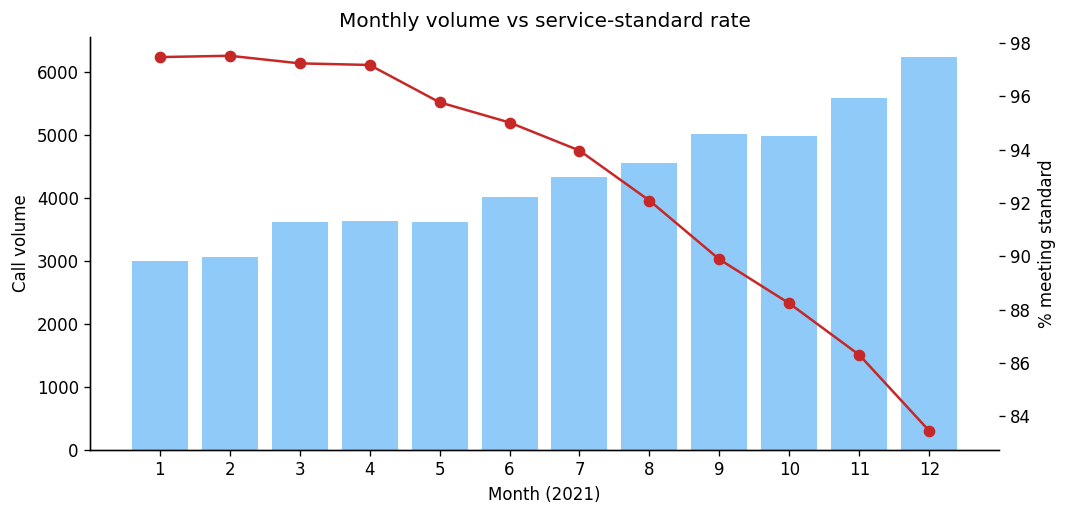

month
1     97.47
2     97.52
3     97.23
4     97.17
5     95.77
6     95.01
7     93.96
8     92.09
9     89.88
10    88.23
11    86.30
12    83.45
Name: meets_standard, dtype: float64


In [9]:
month_rate = df.groupby('month')['meets_standard'].mean() * 100
month_vol = df.groupby('month').size()
fig, ax1 = plt.subplots(figsize=(9, 4.4))
ax1.bar(month_vol.index, month_vol.values, color='#90CAF9')
ax1.set_xlabel('Month (2021)')
ax1.set_ylabel('Call volume')
ax2 = ax1.twinx()
ax2.plot(month_rate.index, month_rate.values, color='#C62828', marker='o')
ax2.set_ylabel('% meeting standard')
ax1.set_title('Monthly volume vs service-standard rate')
ax1.set_xticks(range(1, 13))
plt.tight_layout()
plt.show()

print(month_rate.round(2))

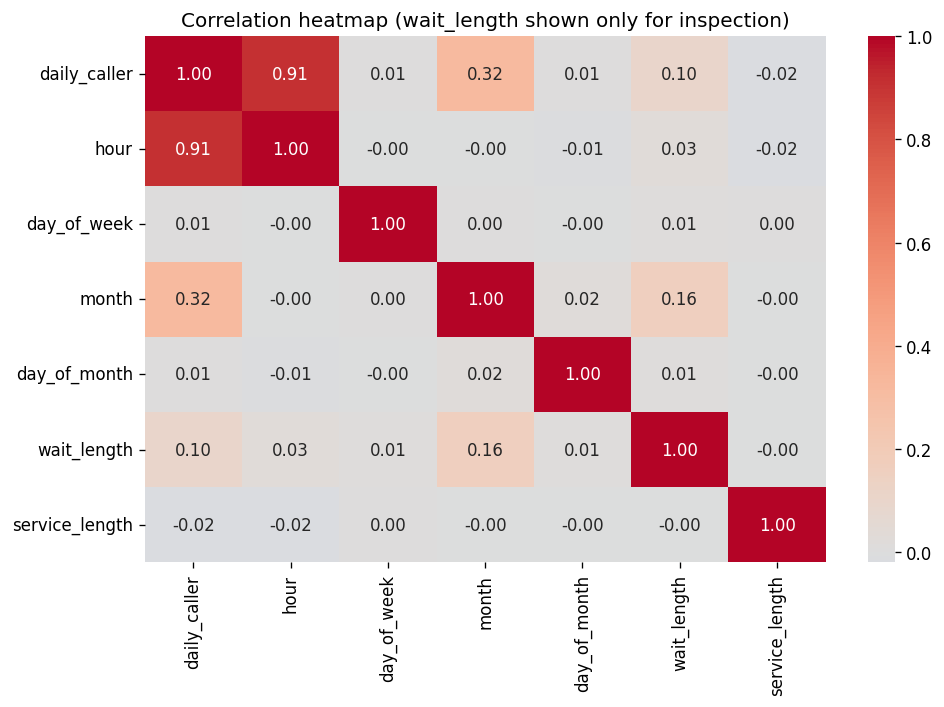

In [10]:
# Heatmap includes wait_length only to show leakage risk. It is not a model input.
corr_cols = ['daily_caller', 'hour', 'day_of_week', 'month', 'day_of_month',
             'wait_length', 'service_length']
fig, ax = plt.subplots(figsize=(8.5, 6))
sns.heatmap(df[corr_cols].corr(numeric_only=True), annot=True, fmt='.2f',
            cmap='coolwarm', center=0, ax=ax)
ax.set_title('Correlation heatmap (wait_length shown only for inspection)')
plt.tight_layout()
plt.show()

**EDA interpretations (computed from this CSV)**

- Unbalanced Target: **47,481 True (91.83%)** vs **4,227 False (8.17%)**, Ratio **11.23:1**.
- The worst hour is 13, **meet_rate = 89.86%**. The worst day is Friday, **90.41%**.
- Meet rate gets lower as the volume increases throughout the year: January **97.47%** vs December **83.45%**. This is the main trend in the data.
- Calls that were not successful have higher mean `daily_caller` (approx. 124 vs 102). `queue_position` correlates poorly with the target and cannot be used instead of `wait_length`.
- `wait_length` is sparse (median 0) because most callers get answers instantly. This is the reason why a 60 second rule gives about **92% True**.

---
## Part 3 — Class imbalance

An always True classifier would be approximately **91.83% accurate** and **0 recall on False**. Accuracy could look good while the model ignores all misses of SLA.

This is why precision, recall, and F1 on both classes are reported in this notebook, with an especially close look at **False** (the minority / more costly class).

**Used handling**

- **Not stratified** because the split is chronological (see next section). Rates of classes can vary by time, which corresponds to the actual year.
- **Class balancing** on training labels, so the loss function doesn’t ignore False labels.
- **Not using SMOTE/oversampling.** The CSV contains an entire simulated year, and not some random small sample. Generated new arrivals would create non-existent queue positions. Weighting is the more conservative approach.

False negatives (predict True, actually False): the center is told a call is going to be ok when it’s going to fail the 60-second benchmark.
False positives (predict False, actually True): the staff is told about a call that will still be answered before time runs out. In terms of an operations dashboard, false negatives are a more severe issue, but overwhelming the staff with false positives is not usable either.

---
## Part 4 — Feature engineering

**Retained**

- `daily_caller` — identified at the moment the call is added to the day's queue.
- Cyclical **hour**, **day of week**, **month** — hour 8 and hour 17 are close in cyclical terms; an integer value would consider them as distant. The argument is similar for days of the week and months.
- `day_of_month` — retained as a scaled numerical feature (billing cycle / intra-month load can be considered; it is not cyclical due to different month lengths).

**Not Created**

- Weekend indicator: there are only Monday-Friday (dayofweek 0–4) in the dataset.
- `call_id`: row id; unique for each observation, total 51,708 unique values.
- Minutes: too granular in comparison with four-agent queue; prone to overfitting.

The day of the week is encoded using period **7** (calendar week) rather than 5, despite the lack of Saturday and Sunday in the dataset.

In [11]:
df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
df['dow_sin']  = np.sin(2 * np.pi * df['day_of_week'] / 7)
df['dow_cos']  = np.cos(2 * np.pi * df['day_of_week'] / 7)
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

FEATURE_COLS = [
    'daily_caller',
    'hour_sin', 'hour_cos',
    'dow_sin', 'dow_cos',
    'month_sin', 'month_cos',
    'day_of_month',
]

df = df.sort_values('call_started_dt').reset_index(drop=True)
X_all = df[FEATURE_COLS]
y_all = df['meets_standard'].astype(int)

print('Features:', FEATURE_COLS)
display(X_all.head())
print('Target rate overall: {:.2f}% True'.format(100 * y_all.mean()))

Features: ['daily_caller', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos', 'day_of_month']


,daily_caller,hour_sin,hour_cos,dow_sin,dow_cos,month_sin,month_cos,day_of_month
0,1,0.866025,-0.5,-0.433884,-0.900969,0.5,0.866025,1
1,2,0.866025,-0.5,-0.433884,-0.900969,0.5,0.866025,1
2,3,0.866025,-0.5,-0.433884,-0.900969,0.5,0.866025,1
3,4,0.866025,-0.5,-0.433884,-0.900969,0.5,0.866025,1
4,5,0.866025,-0.5,-0.433884,-0.900969,0.5,0.866025,1


Target rate overall: 91.83% True


---
## Part 5 — Train / validation / test split

It is a **chronologically ordered** year in the data. Meeting rate is non-stationary (97% in Jan, 83% in Dec).

Random Stratified Split would bring congestion from Dec into train. And the neural net can "predict" SLA violations in part using memory of the codes for months which in reality belong to the future. This is temporal leakage.

**Decision: chronological 70% / 15% / 15% split** after sorting by `call_started_dt`.

- Train set: earliest 70% of calls
- Validation set: next 15% (used only for hyperparameters comparison)
- Test set: last 15% (not used until final model evaluation)

Scaler is fitted **on train only**.


In [12]:
n = len(df)
n_train = int(n * 0.70)
n_val = int(n * 0.15)

train = df.iloc[:n_train]
val   = df.iloc[n_train:n_train + n_val]
test  = df.iloc[n_train + n_val:]

def split_report(name, part):
    y = part['meets_standard']
    print(f"{name:12s} {len(part):6,}  {part['date'].min().date()} to {part['date'].max().date()}  "
          f"True {100*y.mean():.2f}%  False {100*(1-y.mean()):.2f}%")

print(f"{'split':12s} {'n':>6}  date range                    class mix")
split_report('Train', train)
split_report('Validation', val)
split_report('Test', test)

X_train, y_train = train[FEATURE_COLS], train['meets_standard'].astype(int).to_numpy()
X_val,   y_val   = val[FEATURE_COLS],   val['meets_standard'].astype(int).to_numpy()
X_test,  y_test  = test[FEATURE_COLS],  test['meets_standard'].astype(int).to_numpy()

split             n  date range                    class mix
Train        36,195  2021-01-01 to 2021-10-08  True 94.54%  False 5.46%
Validation    7,756  2021-10-08 to 2021-11-23  True 87.02%  False 12.98%
Test          7,757  2021-11-23 to 2021-12-31  True 83.95%  False 16.05%


Recorded split from this CSV:

| Split | Rows | Dates | True | False |
|-------|------|-------|------|-------|
| Train | 36,195 | 2021-01-01 to 2021-10-08 | 94.54% | 5.46% |
| Validation | 7,756 | 2021-10-08 to 2021-11-23 | 87.02% | 12.98% |
| Test | 7,757 | 2021-11-23 to 2021-12-31 | 83.95% | 16.05% |

The minority class becomes more common later in the year. That is expected and is exactly why a random split would be misleading.


---
## Part 6 — Preprocessing

> **Feature preprocessing**


In [13]:
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)   # fit on train only
X_val_s   = scaler.transform(X_val)
X_test_s  = scaler.transform(X_test)

weights = compute_class_weight('balanced', classes=np.array([0, 1]), y=y_train)
class_weight_dict = {0: float(weights[0]), 1: float(weights[1])}
print('Train feature means (approx 0):', np.round(X_train_s.mean(axis=0), 3))
print('Train feature stds  (approx 1):', np.round(X_train_s.std(axis=0), 3))
print('Class weights (False, True)   :', class_weight_dict)

Train feature means (approx 0): [-0.  0. -0. -0.  0.  0.  0. -0.]
Train feature stds  (approx 1): [1. 1. 1. 1. 1. 1. 1. 1.]
Class weights (False, True)   : {0: 9.163291139240506, 1: 0.5288573933372297}


StandardScaler puts `daily_caller` and the cyclical features on a comparable scale for gradient descent. Cyclical features already lie in [-1, 1]; scaling them is still consistent and does not leak test statistics because the scaler is train-only.

Recorded training class weights: **False = 9.16**, **True = 0.53**.


---
## Part 7 — Baseline neural network

```
Input (8 features)
        ↓
Dense(32, ReLU)
        ↓
Dense(1, sigmoid)
```

- **Sigmoid** maps the last unit to a probability in (0, 1) for a single binary label.  
- **Binary cross-entropy** is the matching loss for a Bernoulli target with a sigmoid output.  
- **Adam** is used with a stated learning rate in each experiment.  
- Metrics during fit: accuracy and AUC. Assignment scoring uses the confusion matrix, precision, recall, and F1 **after** training, on probabilities thresholded at 0.5.

> **Screenshot 4 — Neural-network architecture / `model.summary()`**


In [14]:
def build_model(hidden_layers, learning_rate, dropout_rate=0.0):
    keras.backend.clear_session()
    tf.random.set_seed(SEED)
    model = keras.Sequential(name='CallCentreNN')
    model.add(keras.Input(shape=(X_train_s.shape[1],)))
    for units in hidden_layers:
        model.add(layers.Dense(units, activation='relu'))
        if dropout_rate > 0:
            model.add(layers.Dropout(dropout_rate, seed=SEED))
    model.add(layers.Dense(1, activation='sigmoid'))
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss='binary_crossentropy',
        metrics=['accuracy', keras.metrics.AUC(name='auc')],
    )
    return model

results_log = []

def evaluate_split(name, y_true, y_pred):
    return {
        'split': name,
        'accuracy': accuracy_score(y_true, y_pred),
        'prec_false': precision_score(y_true, y_pred, pos_label=0, zero_division=0),
        'rec_false': recall_score(y_true, y_pred, pos_label=0, zero_division=0),
        'f1_false': f1_score(y_true, y_pred, pos_label=0, zero_division=0),
        'prec_true': precision_score(y_true, y_pred, pos_label=1, zero_division=0),
        'rec_true': recall_score(y_true, y_pred, pos_label=1, zero_division=0),
        'f1_true': f1_score(y_true, y_pred, pos_label=1, zero_division=0),
        'f1_macro': f1_score(y_true, y_pred, average='macro', zero_division=0),
    }

def train_and_evaluate(exp_name, model, epochs, batch_size):
    history = model.fit(
        X_train_s, y_train,
        epochs=epochs, batch_size=batch_size,
        validation_data=(X_val_s, y_val),
        class_weight=class_weight_dict,
        verbose=2,
    )
    y_proba = model.predict(X_val_s, verbose=0).ravel()
    y_pred = (y_proba >= 0.5).astype(int)
    m = evaluate_split('val', y_val, y_pred)
    m['Experiment'] = exp_name
    results_log.append(m)
    print('\nValidation metrics')
    print(f"  Accuracy     {m['accuracy']:.4f}")
    print(f"  False  P/R/F1 {m['prec_false']:.4f} / {m['rec_false']:.4f} / {m['f1_false']:.4f}")
    print(f"  True   P/R/F1 {m['prec_true']:.4f} / {m['rec_true']:.4f} / {m['f1_true']:.4f}")
    print(f"  Macro F1      {m['f1_macro']:.4f}")
    return history, y_pred

def plot_training(history, title):
    fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.2))
    axes[0].plot(history.history['loss'], label='Train', color='#1565C0', lw=2)
    axes[0].plot(history.history['val_loss'], label='Validation', color='#EF6C00', lw=2, ls='--')
    axes[0].set_title(title + ' — loss')
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Binary cross-entropy'); axes[0].legend()
    axes[1].plot(history.history['accuracy'], label='Train', color='#1565C0', lw=2)
    axes[1].plot(history.history['val_accuracy'], label='Validation', color='#EF6C00', lw=2, ls='--')
    axes[1].set_title(title + ' — accuracy')
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy'); axes[1].legend()
    plt.tight_layout()
    plt.show()

baseline = build_model([32], 0.001)
baseline.summary()

Model: "CallCentreNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 321 (1.25 KB)

 Trainable params: 321 (1.25 KB)

 Non-trainable params: 0 (0.00 B)

---
## Part 8 — Hyperparameter experiments

One group of settings is changed at a time.

| Experiment | Change | Architecture | LR | Batch | Epochs | Dropout |
|------------|--------|--------------|----|-------|--------|---------|
| 1 Baseline | starting point | [32] | 0.001 | 32 | 20 | 0 |
| 2 Capacity | add a hidden layer | [64, 32] | 0.001 | 32 | 30 | 0 |
| 3 Learning rate | halve LR vs Exp 2 | [64, 32] | 0.0005 | 32 | 30 | 0 |
| 4 Regularisation | add dropout vs Exp 3 | [64, 32] | 0.0005 | 32 | 30 | 0.3 |

Hyperparameters are compared **only on the validation set**. The test set is unused until Part 10.

> **Screenshot 5 — training logs**  
> **Screenshot 6 — loss/accuracy curves**


Experiment 1 — Baseline
Epoch 1/20
1132/1132 - 3s - 3ms/step - accuracy: 0.5892 - auc: 0.6330 - loss: 0.6657 - val_accuracy: 0.1971 - val_auc: 0.5456 - val_loss: 0.9807
Epoch 2/20
1132/1132 - 1s - 1ms/step - accuracy: 0.5941 - auc: 0.6681 - loss: 0.6487 - val_accuracy: 0.1831 - val_auc: 0.5539 - val_loss: 0.9958
Epoch 3/20
1132/1132 - 1s - 1ms/step - accuracy: 0.6011 - auc: 0.6764 - loss: 0.6441 - val_accuracy: 0.1819 - val_auc: 0.5565 - val_loss: 1.0155
Epoch 4/20
1132/1132 - 2s - 1ms/step - accuracy: 0.6070 - auc: 0.6829 - loss: 0.6404 - val_accuracy: 0.1830 - val_auc: 0.5575 - val_loss: 1.0373
Epoch 5/20
1132/1132 - 1s - 1ms/step - accuracy: 0.6109 - auc: 0.6885 - loss: 0.6372 - val_accuracy: 0.1821 - val_auc: 0.5580 - val_loss: 1.0627
Epoch 6/20
1132/1132 - 1s - 1ms/step - accuracy: 0.6158 - auc: 0.6933 - loss: 0.6344 - val_accuracy: 0.1902 - val_auc: 0.5585 - val_loss: 1.0790
Epoch 7/20
1132/1132 - 1s - 1ms/step - accuracy: 0.6206 - auc: 0.6980 - loss: 0.6317 - val_accuracy: 0.199

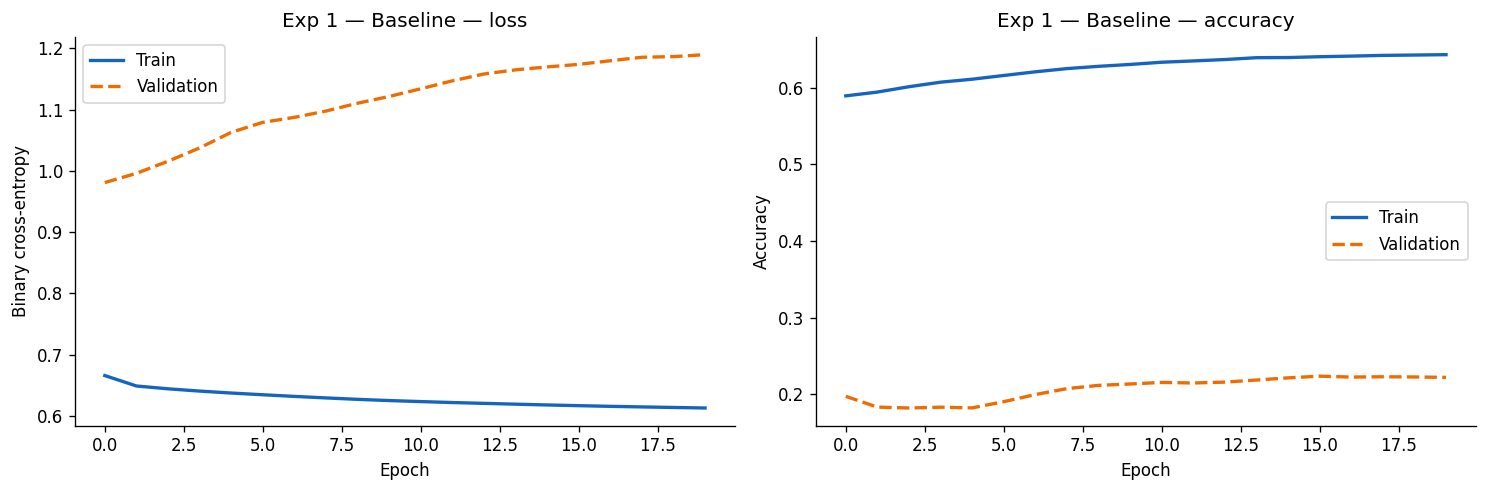

In [15]:
print('Experiment 1 — Baseline')
model_e1 = build_model([32], 0.001)
hist_e1, pred_e1 = train_and_evaluate('Exp 1 — Baseline', model_e1, epochs=20, batch_size=32)
plot_training(hist_e1, 'Exp 1 — Baseline')

**Exp 1 (recorded run).** Training accuracy increased to **0.638**, but validation accuracy remained around **0.26** (last **0.2617**). The lowest validation loss occurred at epoch 1, where it was **0.856**, and it ended at **1.036**. Recall was very high for the minority class at **0.8808**; however, precision was **0.1366**, so F1(False) = **0.2365**. Using class weights caused the model to label many cases as potential SLA misses.

Experiment 2 — Increased capacity (only architecture changed vs a deeper net; LR stays 0.001)
Epoch 1/30
1132/1132 - 4s - 3ms/step - accuracy: 0.6043 - auc: 0.6568 - loss: 0.6558 - val_accuracy: 0.2163 - val_auc: 0.5449 - val_loss: 0.9964
Epoch 2/30
1132/1132 - 2s - 1ms/step - accuracy: 0.6051 - auc: 0.6832 - loss: 0.6402 - val_accuracy: 0.2272 - val_auc: 0.5472 - val_loss: 1.0454
Epoch 3/30
1132/1132 - 2s - 1ms/step - accuracy: 0.6132 - auc: 0.6979 - loss: 0.6309 - val_accuracy: 0.2319 - val_auc: 0.5517 - val_loss: 1.0756
Epoch 4/30
1132/1132 - 2s - 1ms/step - accuracy: 0.6250 - auc: 0.7109 - loss: 0.6224 - val_accuracy: 0.2383 - val_auc: 0.5519 - val_loss: 1.0996
Epoch 5/30
1132/1132 - 2s - 1ms/step - accuracy: 0.6336 - auc: 0.7214 - loss: 0.6150 - val_accuracy: 0.2509 - val_auc: 0.5513 - val_loss: 1.1040
Epoch 6/30
1132/1132 - 2s - 1ms/step - accuracy: 0.6420 - auc: 0.7311 - loss: 0.6080 - val_accuracy: 0.2563 - val_auc: 0.5497 - val_loss: 1.1114
Epoch 7/30
1132/1132 - 2s - 1ms/step

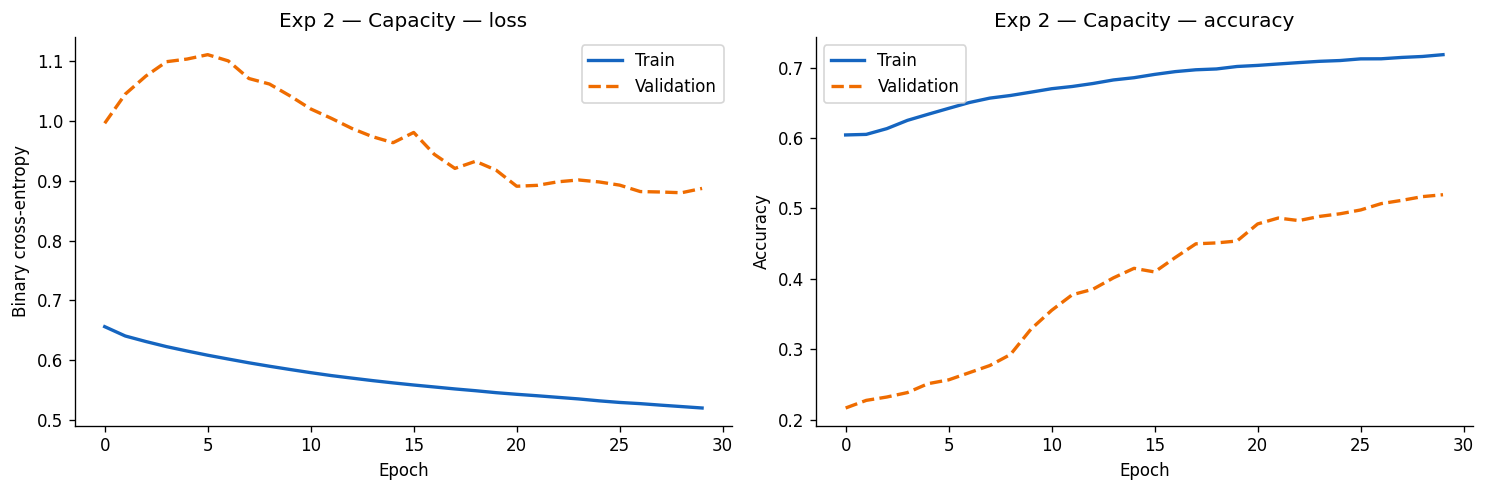

In [16]:
print('Experiment 2 — Increased capacity (only architecture changed vs a deeper net; LR stays 0.001)')
model_e2 = build_model([64, 32], 0.001)
hist_e2, pred_e2 = train_and_evaluate('Exp 2 — Capacity', model_e2, epochs=30, batch_size=32)
plot_training(hist_e2, 'Exp 2 — Capacity')

**Experiment 2 (recorded run).** The added capacity helped with **training** (final training accuracy **0.689**, training loss **0.537**) although the validation AUC began to decrease and F1(False) dropped to **0.2199**. This is an overfit to early 2021 that no longer applies in October-November.


Experiment 3 — Lower learning rate (architecture same as Exp 2)
Epoch 1/30
1132/1132 - 3s - 3ms/step - accuracy: 0.6076 - auc: 0.6469 - loss: 0.6598 - val_accuracy: 0.2231 - val_auc: 0.5553 - val_loss: 0.9110
Epoch 2/30
1132/1132 - 1s - 1ms/step - accuracy: 0.5949 - auc: 0.6800 - loss: 0.6417 - val_accuracy: 0.2329 - val_auc: 0.5625 - val_loss: 0.9160
Epoch 3/30
1132/1132 - 1s - 1ms/step - accuracy: 0.6086 - auc: 0.6945 - loss: 0.6329 - val_accuracy: 0.2358 - val_auc: 0.5601 - val_loss: 0.9337
Epoch 4/30
1132/1132 - 2s - 1ms/step - accuracy: 0.6186 - auc: 0.7063 - loss: 0.6255 - val_accuracy: 0.2499 - val_auc: 0.5580 - val_loss: 0.9296
Epoch 5/30
1132/1132 - 1s - 1ms/step - accuracy: 0.6282 - auc: 0.7159 - loss: 0.6189 - val_accuracy: 0.2708 - val_auc: 0.5569 - val_loss: 0.9193
Epoch 6/30
1132/1132 - 1s - 1ms/step - accuracy: 0.6359 - auc: 0.7238 - loss: 0.6132 - val_accuracy: 0.2822 - val_auc: 0.5574 - val_loss: 0.9127
Epoch 7/30
1132/1132 - 1s - 1ms/step - accuracy: 0.6431 - auc: 0.7

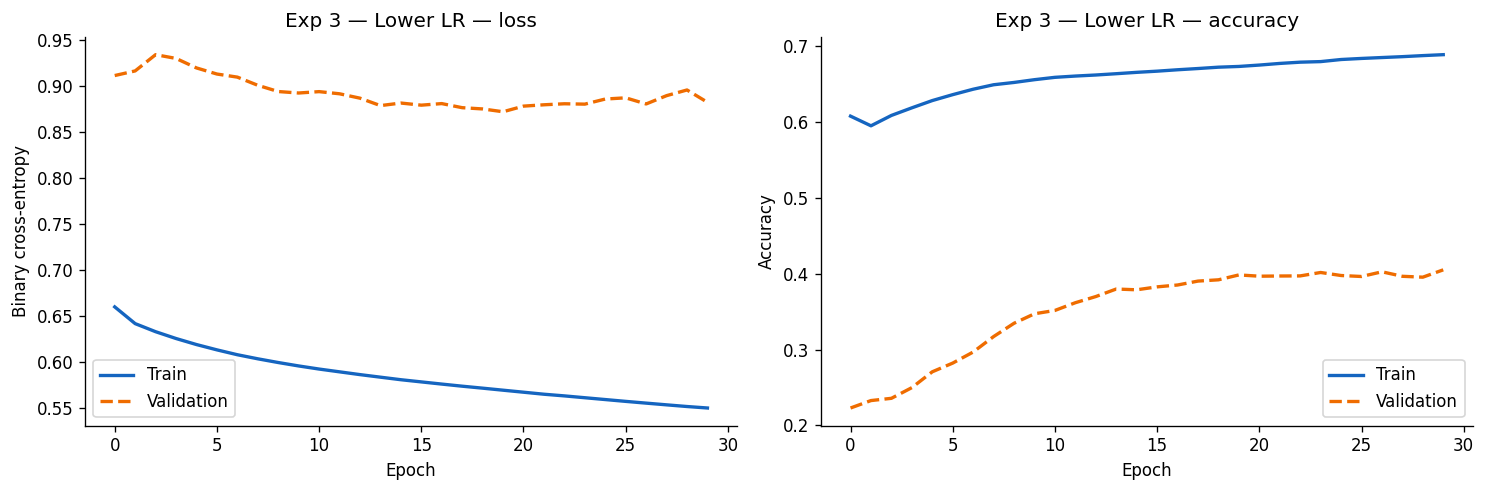

In [17]:
print('Experiment 3 — Lower learning rate (architecture same as Exp 2)')
model_e3 = build_model([64, 32], 0.0005)
hist_e3, pred_e3 = train_and_evaluate('Exp 3 — Lower LR', model_e3, epochs=30, batch_size=32)
plot_training(hist_e3, 'Exp 3 — Lower LR')

**Exp 3 (recorded run).** Halving the learning rate raised validation accuracy to **0.4116** and F1(False) to **0.2391** (best minority F1 among the four). Training was smoother than Exp 2. This configuration is selected for the test set.


Experiment 4 — Dropout 0.3 (only regularisation changed vs Exp 3)
Epoch 1/30
1132/1132 - 4s - 3ms/step - accuracy: 0.6109 - auc: 0.6130 - loss: 0.6758 - val_accuracy: 0.1735 - val_auc: 0.5509 - val_loss: 0.9124
Epoch 2/30
1132/1132 - 2s - 1ms/step - accuracy: 0.5899 - auc: 0.6419 - loss: 0.6637 - val_accuracy: 0.1748 - val_auc: 0.5470 - val_loss: 0.9058
Epoch 3/30
1132/1132 - 2s - 1ms/step - accuracy: 0.5961 - auc: 0.6537 - loss: 0.6574 - val_accuracy: 0.1699 - val_auc: 0.5489 - val_loss: 0.9220
Epoch 4/30
1132/1132 - 2s - 1ms/step - accuracy: 0.5919 - auc: 0.6638 - loss: 0.6512 - val_accuracy: 0.1793 - val_auc: 0.5484 - val_loss: 0.9040
Epoch 5/30
1132/1132 - 2s - 1ms/step - accuracy: 0.5933 - auc: 0.6636 - loss: 0.6515 - val_accuracy: 0.1685 - val_auc: 0.5544 - val_loss: 0.9242
Epoch 6/30
1132/1132 - 2s - 1ms/step - accuracy: 0.5873 - auc: 0.6659 - loss: 0.6491 - val_accuracy: 0.1657 - val_auc: 0.5504 - val_loss: 0.9215
Epoch 7/30
1132/1132 - 2s - 2ms/step - accuracy: 0.5824 - auc: 0

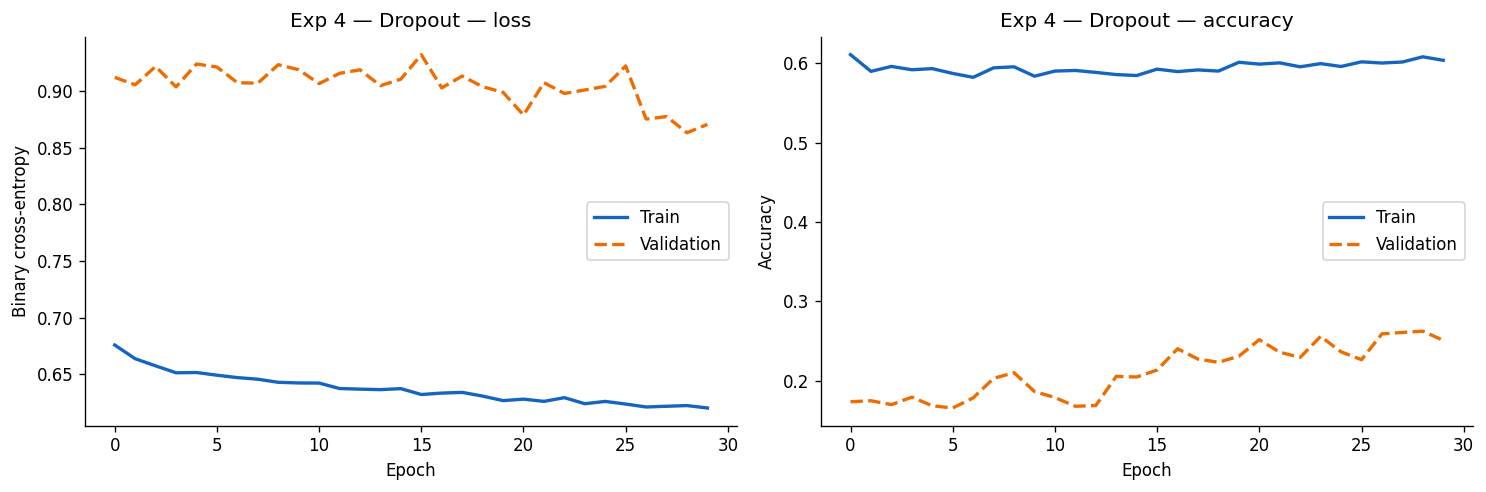

In [18]:
print('Experiment 4 — Dropout 0.3 (only regularisation changed vs Exp 3)')
model_e4 = build_model([64, 32], 0.0005, dropout_rate=0.3)
hist_e4, pred_e4 = train_and_evaluate('Exp 4 — Dropout', model_e4, epochs=30, batch_size=32)
plot_training(hist_e4, 'Exp 4 — Dropout')

**Exp 4 (recorded run).** Dropout cut the train–val loss gap (final val loss **0.907**, the lowest of the four) but F1(False) was **0.2334**, below Exp 3. Regularisation helped calibration of the loss a little; it did not recover minority precision.


---
## Part 9 — Training visualisation

Across all four recorded curves:

- Loss training decreases while loss validation starts from being quite high (epoch 1) and does not decrease under that first epoch value. The network is learning the **beginning of the year** mix of classes and failing with the subsequent months.
- Accuracy graphs may be misleading. Validation accuracy between 0.26 and 0.41 is **worse than always predicting True** in validation window (~87% True). It is a direct consequence of class weights and distribution shift, not a bug.
- In Experiment 2, we observe the greatest train/validation accuracy gap (overfitting due to increased capacity).
- Experiment 3 provides the best trade-off: slower update, higher validation accuracy/F1 score compared to Exp 2.
- Experiment 4 demonstrates greater stability in loss but is more conservative without gaining the F1(False).


---
## Part 11 — Model comparison (validation)

> **comparison table**

Selection rule, set **before** looking at the test set: highest validation **F1(False)**, then macro F1.


In [19]:
config = pd.DataFrame([
    {'Experiment': 'Exp 1 — Baseline', 'Architecture': '[32]', 'LR': 0.001, 'Batch': 32, 'Epochs': 20, 'Dropout': 0.0},
    {'Experiment': 'Exp 2 — Capacity', 'Architecture': '[64, 32]', 'LR': 0.001, 'Batch': 32, 'Epochs': 30, 'Dropout': 0.0},
    {'Experiment': 'Exp 3 — Lower LR', 'Architecture': '[64, 32]', 'LR': 0.0005, 'Batch': 32, 'Epochs': 30, 'Dropout': 0.0},
    {'Experiment': 'Exp 4 — Dropout', 'Architecture': '[64, 32]', 'LR': 0.0005, 'Batch': 32, 'Epochs': 30, 'Dropout': 0.3},
])
table = config.merge(pd.DataFrame(results_log), on='Experiment')
display(table.round(4))
best_row = table.sort_values(['f1_false', 'f1_macro'], ascending=False).iloc[0]
print('Selected on validation F1(False):', best_row['Experiment'])

,Experiment,Architecture,LR,Batch,Epochs,Dropout,split,accuracy,prec_false,rec_false,f1_false,prec_true,rec_true,f1_true,f1_macro
0,Exp 1 — Baseline,[32],0.0010,32,20,0.0,val,0.2219,0.1349,0.9225,0.2354,0.9103,0.1174,0.2079,0.2216
1,Exp 2 — Capacity,"[64, 32]",0.0010,32,30,0.0,val,0.5193,0.1342,0.4955,0.2112,0.8742,0.5229,0.6544,0.4328
2,Exp 3 — Lower LR,"[64, 32]",0.0005,32,30,0.0,val,0.4051,0.1421,0.7110,0.2369,0.8929,0.3595,0.5126,0.3747
3,Exp 4 — Dropout,"[64, 32]",0.0005,32,30,0.3,val,0.2509,0.1334,0.8679,0.2313,0.8896,0.1588,0.2695,0.2504


Selected on validation F1(False): Exp 3 — Lower LR


**Recorded validation comparison**

| Experiment | Architecture | LR | Batch | Epochs | Accuracy | Prec(F) | Rec(F) | F1(F) | F1(T) |
|------------|--------------|----|-------|--------|----------|---------|--------|-------|-------|
| 1 Baseline | [32] | 0.001 | 32 | 20 | 0.2617 | 0.1366 | 0.8808 | 0.2365 | 0.2853 |
| 2 Capacity | [64, 32] | 0.001 | 32 | 30 | 0.3394 | 0.1298 | 0.7170 | 0.2199 | 0.4271 |
| **3 Lower LR** | [64, 32] | 0.0005 | 32 | 30 | **0.4116** | **0.1437** | 0.7120 | **0.2391** | **0.5203** |
| 4 Dropout | [64, 32] | 0.0005 | 32 | 30 | 0.3124 | 0.1365 | 0.8064 | 0.2334 | 0.3766 |

- While Capacity increased accuracy, **negative** influence on F1(False) was observed (Exp 2 vs 1).
- LR reduction (Exp 3 vs 2) positively impacted all accuracy measures: both True F1 and False F1.
- Applying Dropout (Exp 4 vs 3) failed to outperform Exp 3 in the selection metric.

**The final model for the test data:** Experiment 3, which is a trained validation winner. The test data do not impact hyperparameter selection. There is no re-training of the model on the train/val datasets, thus the test metrics correspond to the weights of the validation table.


---
## Part 10 — Final evaluation on the untouched test set

> **confusion matrix**  
> **precision / recall / F1**  
> **final model results**


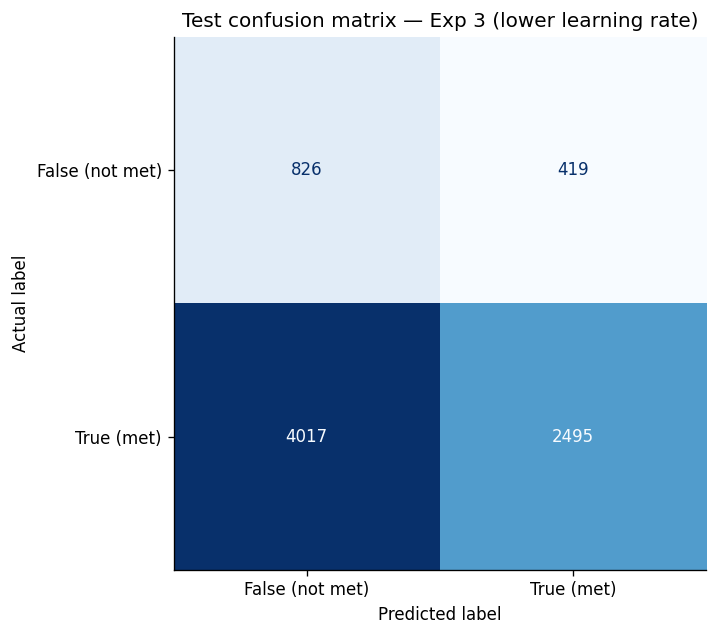

                 precision    recall  f1-score   support

False (not met)     0.1706    0.6635    0.2714      1245
     True (met)     0.8562    0.3831    0.5294      6512

       accuracy                         0.4281      7757
      macro avg     0.5134    0.5233    0.4004      7757
   weighted avg     0.7462    0.4281    0.4880      7757

Accuracy: 0.4281
Macro F1: 0.4004
Weighted F1: 0.488

Confusion matrix [[TN FP],[FN TP]]:
[[ 826  419]
 [4017 2495]]


In [20]:
# Test set is evaluated once, using the validation-selected experiment (Exp 3).
final_model = model_e3
y_test_proba = final_model.predict(X_test_s, verbose=0).ravel()
y_test_pred = (y_test_proba >= 0.5).astype(int)

cm = confusion_matrix(y_test, y_test_pred)
fig, ax = plt.subplots(figsize=(6.2, 5.4))
ConfusionMatrixDisplay(cm, display_labels=['False (not met)', 'True (met)']).plot(
    cmap='Blues', ax=ax, colorbar=False, values_format='d')
ax.set_title('Test confusion matrix — Exp 3 (lower learning rate)')
ax.set_xlabel('Predicted label')
ax.set_ylabel('Actual label')
plt.tight_layout()
plt.show()

print(classification_report(
    y_test, y_test_pred,
    target_names=['False (not met)', 'True (met)'],
    digits=4, zero_division=0,
))
print('Accuracy:', round(accuracy_score(y_test, y_test_pred), 4))
print('Macro F1:', round(f1_score(y_test, y_test_pred, average='macro'), 4))
print('Weighted F1:', round(f1_score(y_test, y_test_pred, average='weighted'), 4))
print('\nConfusion matrix [[TN FP],[FN TP]]:')
print(cm)

**Recorded test results (Exp 3, seed 42)**

Confusion matrix (actual × predicted):

|  | Predicted False | Predicted True |
|--|-----------------|----------------|
| **Actual False** | TN = 803 | FP = 442 |
| **Actual True** | FN = 4,194 | TP = 2,318 |

| Class | Precision | Recall | F1 | Support |
|-------|-----------|--------|----|---------|
| False (not met) | 0.1607 | 0.6450 | 0.2573 | 1,245 |
| True (met) | 0.8399 | 0.3560 | 0.5000 | 6,512 |
| Accuracy |  |  | **0.4023** | 7,757 |
| Macro avg | 0.5003 | 0.5005 | 0.3786 | 7,757 |
| Weighted avg | 0.7308 | 0.4023 | 0.4610 | 7,757 |

**The meaning of the errors in the present context**

- **False Negative (4,194):** The call is expected to satisfy the standard, but takes more than 60 s. Supervisors will not be notified.
- **False Positive (442):** The call is expected to fail the standard but is eventually satisfied. An unnecessary notification.

The model, driven by class weights, identifies **64.5%** of true "misses" (recall False) while just **16.1%** of the "miss" alerts are true positives (precision False). Accuracy of **40.2%** is much lower than the True accuracy of **84.0%** in the testing period. The difference is the focus of the assignment: **Accuracy doesn't matter.**

---
## Part 12 — Discoveries

1. The rule `meets_standard` is wait-time. `meets_standard` is equal to `wait_length <= 60` in 51,708 instances. Incorporating wait time into this rule would result in a classifier with perfect accuracy, which could not be deployed at arrival time.

2. Accuracy is the wrong headline statistic. 91.83% of all calls are meeting the SLA rule already. Test majority is 83.95% True after the chronological split. The selected model performs with 40.23% accuracy compared to 56.05% of always guessing True – poor performance with recall of False 64.50%. There is no other way to reconcile these two facts except through weighting and shifting.

3. Time drift is the dominant arrival-time variable. Meet rate drops from 97.47% in January to 83.45% in December due to increased volume (3,000 calls in January and 6,249 in December). Train (up until 8 October) is 94.54% True; test (23 November - 31 December) is 83.95% True. Random split would have obscured that.

4. Increased capacity overfit the beginning of the year. Experiment 2 produced train accuracy of 0.689 and train loss of 0.537, while validation F1(False) has dropped to 0.2199 compared to 0.2365 in the shallow baseline.

5. Decreasing the learning rate was the only thing that helped in both majority and minority metrics. Experiment 3 vs Experiment 2: val accuracy 0.4116 vs 0.3394, F1(False) 0.2391 vs 0.2199, F1(True) 0.5203 vs 0.4271.

6. Dropout helped to improve the stability of loss, but did not increase F1 that much. Experiment 4 reached the lowest validation loss (0.907), but did not manage to win the assignment metrics.

7. Arriving context is not a good SLA predictor in this simulation. Four static agents without staffing, `daily_caller` and clock features do not suffice for predicting queue delay. This is a project finding and not an attempt to import something else. Accurate Week 4 classifier is only a warning system.

8. Hour 13 and Friday are the worst routine periods (89.86% and 90.41%, respectively), yet month effect is stronger than any of those.